In [ ]:
import cooler
import cooltools
import pandas as pd
from ggner_3d.cm import scaled_balanced_cool_dump_streaming, CLR_CONNS
from ggner_3d.boundaries import preserved_boundaries_only, make_tads, genomewide_full_tad2tad_from_pixel_field, genomewide_full_tad2tad_from_pixel_field_full

from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

cis_only = False

In [ ]:
def make_view_df(clr_conn):
    return pd.DataFrame({'chrom': clr_conn.chromnames,
                        'start': 0,
                        'end': clr_conn.chromsizes.values,
                        'name': clr_conn.chromnames}
                      )

In [ ]:
def get_clr_dict(res):
    us2os_clr = CLR_CONNS(res)
    clr_dict = {
    'control_pol2_clr': cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/degron_pol2/GSM5394172_control_mergeRep_500bp.mcool::/resolutions/{res}"),
    'degron_pol2_clr': cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/degron_pol2/GSM5394173_degron_mergeRep_500bp.mcool::/resolutions/{res}"),
    # 'control_rad21_clr': cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/degron_rad21/GSE178982_RAD21-UT_pool.mcool::/resolutions/{res}"),
    # 'degron_rad21_clr': cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/degron_rad21/GSE178982_RAD21-AID_pool.mcool::/resolutions/{res}"),
    'control_wapl_clr': cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/degron_wapl/GSE178982_WAPL-UT_pool.mcool::/resolutions/{res}"),
    'degron_wapl_clr': cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/degron_wapl/GSE178982_WAPL-AID_pool.mcool::/resolutions/{res}"),
    'wt_nouv_clr': us2os_clr['WTnoUV'],
    'wt_1h_clr': us2os_clr['WT1h'],
    'wt_3h_clr': us2os_clr['WT3h'],
    'wt_6h_clr': us2os_clr['WT6h'],
    'xpc_nouv_clr': us2os_clr['XPCnoUV'],
    'xpc_3h_clr': us2os_clr['XPC3h'],
    'hela_nouv_clr': cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/hela/GSM8289939_t0_q30.mcool::/resolutions/{res}"),
    'hela_12mins': cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/hela/GSM8289940_t12_q30.mcool::/resolutions/{res}")
    }
    return clr_dict

weights_dict = {
    'control_pol2_clr': 'weight',
    'degron_pol2_clr': 'weight',
    'control_rad21_clr': 'weight',
    'degron_rad21_clr': 'weight',
    'control_wapl_clr': 'weight',
    'degron_wapl_clr': 'weight',
    'wt_nouv_clr': 'sweight',
    'wt_1h_clr': 'sweight',
    'wt_3h_clr': 'sweight',
    'wt_6h_clr': 'sweight',
    'xpc_nouv_clr': 'sweight',
    'xpc_3h_clr': 'sweight',
    'hela_nouv_clr': 'weight',
    'hela_12mins': 'weight'
}

### prepare scaled cool files

In [ ]:
dump_folder = '/home/carlos/Clone/ggner-3d/data/scaled_cools'
resolution_for_scaling = 100_000
scaling_dict = get_clr_dict(resolution_for_scaling)

In [ ]:
for sample_name, clr in scaling_dict.items():
    view_df = make_view_df(clr)

    if sample_name != 'xpc_3h_clr':
        continue
    
    current_weight = weights_dict[sample_name]
    print(f"Dumping {sample_name} with weight: {current_weight}...")
    scaled_balanced_cool_dump_streaming(
        clr=clr,
        dump_path = f"{dump_folder}/{sample_name}_scaled_balanced_{resolution_for_scaling}.cool",
        cis_only=cis_only,
        weight_name=current_weight,
    )

In [ ]:
scaled_clr_dict = {
    'control_pol2_clr': cooler.Cooler(f"{dump_folder}/control_pol2_clr_scaled_balanced_{resolution_for_scaling}.cool"),
    'degron_pol2_clr': cooler.Cooler(f"{dump_folder}/degron_pol2_clr_scaled_balanced_{resolution_for_scaling}.cool"),
    # 'control_rad21_clr': cooler.Cooler(f"{dump_folder}/control_rad21_clr_scaled_balanced_{resolution_for_scaling}.cool"),
    # 'degron_rad21_clr': cooler.Cooler(f"{dump_folder}/degron_rad21_clr_scaled_balanced_{resolution_for_scaling}.cool"),
    'control_wapl_clr': cooler.Cooler(f"{dump_folder}/control_wapl_clr_scaled_balanced_{resolution_for_scaling}.cool"),
    'degron_wapl_clr': cooler.Cooler(f"{dump_folder}/degron_wapl_clr_scaled_balanced_{resolution_for_scaling}.cool"),
    'wt_nouv_clr': cooler.Cooler(f"{dump_folder}/wt_nouv_clr_scaled_balanced_{resolution_for_scaling}.cool"),
    'wt_1h_clr': cooler.Cooler(f"{dump_folder}/wt_1h_clr_scaled_balanced_{resolution_for_scaling}.cool"),
    'wt_3h_clr': cooler.Cooler(f"{dump_folder}/wt_3h_clr_scaled_balanced_{resolution_for_scaling}.cool"),
    'wt_6h_clr': cooler.Cooler(f"{dump_folder}/wt_6h_clr_scaled_balanced_{resolution_for_scaling}.cool"),
    'xpc_nouv_clr': cooler.Cooler(f"{dump_folder}/xpc_nouv_clr_scaled_balanced_{resolution_for_scaling}.cool"),
    'xpc_3h_clr': cooler.Cooler(f"{dump_folder}/xpc_3h_clr_scaled_balanced_{resolution_for_scaling}.cool"),
    'hela_nouv_clr': cooler.Cooler(f"{dump_folder}/hela_nouv_clr_scaled_balanced_{resolution_for_scaling}.cool"),
    'hela_12mins': cooler.Cooler(f"{dump_folder}/hela_12mins_scaled_balanced_{resolution_for_scaling}.cool")
}

### prepare tads

In [ ]:
def chrom_to_bin_indices(df, bins_table, bin_column = 'idx1'):
    df = df.copy()
    bins_table['indices'] = bins_table.index
    return pd.merge(df, bins_table, left_on=bin_column, right_on='indices')

def prepare_tads_for_comp(control_clr, ins_df_control, ins_df_treatment, window=500_000):
    insulation_table_ = [ins_df_control, ins_df_treatment]
    comparisons = [(0,1)]
    comparisons_str = ['control_vs_treatment']
    sample_names_str = ['control', 'treatment']
    accepted_range = 1

    results, dfs = preserved_boundaries_only(
    comparisons=comparisons,
    comparisons_str=comparisons_str,
    sample_names_str=sample_names_str,
    accepted_range=accepted_range,
    insulation_table_=insulation_table_,
    window=window,
    )

    dfs = [
        chrom_to_bin_indices(df, control_clr.bins()[:], bin_column='idx1') for df in dfs
    ]

    common_tads = make_tads(
    insul_df=dfs[0][['chrom', 'start', 'end']],
    maxlen=3e6)
    
    return common_tads

_10kb_clr_dict = get_clr_dict(10_000)

In [ ]:
common_tads_pol2 = prepare_tads_for_comp(
    control_clr=_10kb_clr_dict['control_pol2_clr'],
    ins_df_control=pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron_pol2/control_insulation_10kb_500000_window.csv'),
    ins_df_treatment=pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron_pol2/degron_insulation_10kb_500000_window.csv'),
    window=500_000
)


common_tads_wt_per_post_uv = prepare_tads_for_comp(
    control_clr=_10kb_clr_dict['wt_nouv_clr'],
    ins_df_control=pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WTnoUV_10000bp.csv'),
    ins_df_treatment=pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WT3h_10000bp.csv'),
    window=500_000
)

common_tads_wapl = prepare_tads_for_comp(
    control_clr=_10kb_clr_dict['control_wapl_clr'],
    ins_df_control=pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron_wapl/control_insulation.tsv', sep='\t'),
    ins_df_treatment=pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron_wapl/degron_insulation.tsv', sep='\t'),
    window=500_000
)

# common_tads_rad21 = prepare_tads_for_comp(
#     control_clr=_10kb_clr_dict['control_rad21_clr'],
#     ins_df_control=pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron_rad21/control_insulation_10kb_500000_window.csv'),
#     ins_df_treatment=pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron_rad21/degron_insulation_10kb_500000_window.csv'),
#     window=500_000
# )

common_tads_hela = prepare_tads_for_comp(
    control_clr=_10kb_clr_dict['hela_nouv_clr'],
    ins_df_control=pd.read_csv('/home/carlos/Clone/ggner-3d/data/hela/insulation_500000_t0.tsv', sep='\t'),
    ins_df_treatment=pd.read_csv('/home/carlos/Clone/ggner-3d/data/hela/insulation_500000_t12.tsv', sep='\t'),
    window=500_000
)

common_tads_wtnouv_xpcnouv = prepare_tads_for_comp(
    control_clr=_10kb_clr_dict['wt_nouv_clr'],
    ins_df_control=pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WTnoUV_10000bp.csv'),
    ins_df_treatment=pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_XPCnoUV_10000bp.csv'),
    window=500_000
)


common_tads_xpc_nouv_xpc_3h = prepare_tads_for_comp(
    control_clr=_10kb_clr_dict['xpc_nouv_clr'],
    ins_df_control=pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_XPCnoUV_10000bp.csv'),
    ins_df_treatment=pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_XPC3h_10000bp.csv'),
    window=500_000
)

common_tads_wt_nouv_wt_1h = prepare_tads_for_comp(
    control_clr=_10kb_clr_dict['wt_nouv_clr'],
    ins_df_control=pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WTnoUV_10000bp.csv'),
    ins_df_treatment=pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WT1h_10000bp.csv'),
    window=500_000
)

common_tads_wt_nouv_wt_6h = prepare_tads_for_comp(
    control_clr=_10kb_clr_dict['wt_nouv_clr'],
    ins_df_control=pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WTnoUV_10000bp.csv'),
    ins_df_treatment=pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WT6h_10000bp.csv'),
    window=500_000
)

In [47]:
def tad2tad(tads_common, clr_control, clr_treatment, agg='sum'):
    control_mtx, control_meta, control_per = genomewide_full_tad2tad_from_pixel_field(
    clr_control,
    tads_common,
    field="scaled",
    agg=agg,
    ignore_diagonal=2,
    )
    print("Control done, starting treatment...")

    treatment_mtx, treatment_meta, treatment_per = genomewide_full_tad2tad_from_pixel_field(
    clr_treatment,
    tads_common,
    field="scaled",
    agg=agg,
    ignore_diagonal=2,
    )
    print("Treatment done.")

    return control_mtx, treatment_mtx, control_meta

pol2_tads_control_mtx, pol2_tads_treatment_mtx, pol2_tads_meta = tad2tad(
    tads_common=common_tads_pol2,
    clr_control=scaled_clr_dict['control_pol2_clr'],
    clr_treatment=scaled_clr_dict['degron_pol2_clr'],
    agg='sum',
)

wapl_tads_control_mtx, wapl_tads_treatment_mtx, wapl_tads_meta = tad2tad(
    tads_common=common_tads_wapl,
    clr_control=scaled_clr_dict['control_wapl_clr'],
    clr_treatment=scaled_clr_dict['degron_wapl_clr'],
    agg='sum',
)

# rad21_tads_control_mtx, rad21_tads_treatment_mtx, rad21_tads_meta = tad2tad(
#     tads_common=common_tads_rad21,
#     clr_control=scaled_clr_dict['control_rad21_clr'],
#     clr_treatment=scaled_clr_dict['degron_rad21_clr'],
#     agg='sum',
# )

# hela_tads_control_mtx, hela_tads_treatment_mtx, hela_tads_meta = tad2tad(
#     tads_common=common_tads_hela,
#     clr_control=scaled_clr_dict['hela_nouv_clr'],
#     clr_treatment=scaled_clr_dict['hela_12mins'],
#     agg='sum',
# )

Control done, starting treatment...
Treatment done.
Control done, starting treatment...
Treatment done.


In [48]:
wt_per_post_uv_tads_control_mtx, wt_per_post_uv_tads_treatment_mtx, wt_per_post_uv_tads_meta = tad2tad(
    tads_common=common_tads_wt_per_post_uv,
    clr_control=scaled_clr_dict['wt_nouv_clr'],
    clr_treatment=scaled_clr_dict['wt_3h_clr'],
    agg='sum',
)

Control done, starting treatment...
Treatment done.


In [49]:
wt_nouv_xpc_nouv_tads_control_mtx, wt_nouv_xpc_nouv_tads_treatment_mtx, wt_nouv_xpc_nouv_tads_meta = tad2tad(
    tads_common=common_tads_wtnouv_xpcnouv,
    clr_control=scaled_clr_dict['wt_nouv_clr'],
    clr_treatment=scaled_clr_dict['xpc_nouv_clr'],
    agg='sum',
)

Control done, starting treatment...
Treatment done.


In [50]:
xpc_nouv_tads_control_mtx, xpc_3h_tads_treatment_mtx, xpc_nouv_tads_meta = tad2tad(
    tads_common=common_tads_xpc_nouv_xpc_3h,
    clr_control=scaled_clr_dict['xpc_nouv_clr'],
    clr_treatment=scaled_clr_dict['xpc_3h_clr'],
    agg='sum',
)

Control done, starting treatment...
Treatment done.


In [51]:
wt_nouv_wt_1h_tads_control_mtx, wt_nouv_wt_1h_tads_treatment_mtx, wt_nouv_wt_1h_tads_meta = tad2tad(
    tads_common=common_tads_wt_nouv_wt_1h,
    clr_control=scaled_clr_dict['wt_nouv_clr'],
    clr_treatment=scaled_clr_dict['wt_1h_clr'],
    agg='sum',
)

Control done, starting treatment...
Treatment done.


In [52]:
wt_nouv_wt_6h_tads_control_mtx, wt_nouv_wt_6h_tads_treatment_mtx, wt_nouv_wt_6h_tads_meta = tad2tad(
    tads_common=common_tads_wt_nouv_wt_6h,
    clr_control=scaled_clr_dict['wt_nouv_clr'],
    clr_treatment=scaled_clr_dict['wt_6h_clr'],
    agg='sum',
)

Control done, starting treatment...
Treatment done.


In [53]:
def id_start(meta, chrom):
    sizes_all = list(meta['sizes'].values())
    chrom_idx = list(meta['sizes'].keys()).index(chrom)
    sum_pre = sum(sizes_all[:chrom_idx])
    end = sum_pre + meta['sizes'][chrom]
    return sum_pre, end

In [54]:
from ggner_3d.cm import prepare_view_df
view_df_arm = prepare_view_df()

def get_arm_boundary_tad_idx_dict(tad_df, arm_df, which="last_p"):
    """
    Return a dict mapping chromosome -> per-chromosome TAD index at the p/q arm boundary.

    Parameters
    ----------
    tad_df : pd.DataFrame
        Must contain columns: ['chrom', 'start', 'end']
    arm_df : pd.DataFrame
        Must contain columns: ['chrom', 'start', 'end', 'name']
        p-arm rows should have names ending with '_p'
    which : str
        One of:
        - 'last_p'   : last TAD fully on p arm
        - 'first_q'  : first TAD fully on q arm
        - 'overlap'  : TAD crossing the p/q boundary

    Returns
    -------
    dict
        Example:
        {'chr1': 123, 'chr2': 23, ...}
        Values are per-chromosome 0-based TAD indices.
        If no matching TAD exists for a chromosome, value is None.
    """
    import pandas as pd

    # p-arm end gives the p/q boundary
    p_arms = (
        arm_df[arm_df["name"].str.endswith("_p")]
        [["chrom", "end"]]
        .rename(columns={"end": "boundary"})
        .copy()
    )

    out = {}

    for _, row in p_arms.iterrows():
        chrom = row["chrom"]
        boundary = row["boundary"]

        t = tad_df[tad_df["chrom"] == chrom].copy()
        t = t.reset_index(drop=True)  # makes index per-chromosome

        if which == "last_p":
            hits = t[t["end"] <= boundary]
            out[chrom] = None if hits.empty else int(hits.index[-1])

        elif which == "first_q":
            hits = t[t["start"] >= boundary]
            out[chrom] = None if hits.empty else int(hits.index[0])

        elif which == "overlap":
            hits = t[(t["start"] < boundary) & (t["end"] > boundary)]
            out[chrom] = None if hits.empty else int(hits.index[0])

        else:
            raise ValueError("which must be one of: 'last_p', 'first_q', 'overlap'")

    return out

In [55]:
comparisons = [
    # (('HELA', 'HELA 12min'), hela_tads_control_mtx, hela_tads_treatment_mtx, hela_tads_meta, common_tads_hela),
    (('WT nouv', 'WT 1h post UV'), wt_nouv_wt_1h_tads_control_mtx, wt_nouv_wt_1h_tads_treatment_mtx, wt_nouv_wt_1h_tads_meta, common_tads_wt_nouv_wt_1h),
    (('WT nouv', 'WT 3h post UV'), wt_per_post_uv_tads_control_mtx, wt_per_post_uv_tads_treatment_mtx, wt_per_post_uv_tads_meta, common_tads_wt_per_post_uv),
    (('WT nouv', 'WT 6h post UV'), wt_nouv_wt_6h_tads_control_mtx, wt_nouv_wt_6h_tads_treatment_mtx, wt_nouv_wt_6h_tads_meta, common_tads_wt_nouv_wt_6h),
    (('XPCnoUV', 'XPC 3h post UV'), xpc_nouv_tads_control_mtx, xpc_3h_tads_treatment_mtx, xpc_nouv_tads_meta, common_tads_xpc_nouv_xpc_3h),
    (('WTnoUV', 'XPCnoUV'), wt_nouv_xpc_nouv_tads_control_mtx, wt_nouv_xpc_nouv_tads_treatment_mtx, wt_nouv_xpc_nouv_tads_meta, common_tads_wtnouv_xpcnouv),
    (('Pol2', 'Pol2 degron'), pol2_tads_control_mtx, pol2_tads_treatment_mtx, pol2_tads_meta, common_tads_pol2),
    (('WAPL', 'WAPL degron'), wapl_tads_control_mtx, wapl_tads_treatment_mtx, wapl_tads_meta, common_tads_wapl),
]

In [75]:
import gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cooltools


ignore_diag = 1
eps = 1e-12


def normalize_mtx(mtx, perc_min, perc_max):
    vmin = np.nanpercentile(mtx, perc_min)
    vmax = np.nanpercentile(mtx, perc_max)
    mtx_clipped = np.where(mtx < vmin, vmin, mtx)
    mtx_clipped = np.where(mtx_clipped > vmax, vmax, mtx_clipped)
    return mtx_clipped


for coi in view_df_arm["chrom"].unique():
    fig, axs = plt.subplots(
        len(comparisons),
        3,
        figsize=(18, 12 * len(comparisons)),
        squeeze=False,
    )

    for i, comp in enumerate(comparisons):
        l1, l2 = comp[0]
        meta = comp[3]
        tads_common = comp[4]

        tads_common_indices = get_arm_boundary_tad_idx_dict(
            tads_common, view_df_arm, which="last_p"
        )[coi]

        if tads_common_indices is None:
            continue

        if coi not in meta['chrom_order']:
            continue
        chrom_start, chrom_end = id_start(meta, coi)

        # slice first, then copy only the needed submatrix
        mtx1 = comp[1][chrom_start:chrom_end, chrom_start:chrom_end].copy()
        mtx2 = comp[2][chrom_start:chrom_end, chrom_start:chrom_end].copy()

        if ignore_diag >= 0:
            for diag in range(-ignore_diag, ignore_diag + 1):
                cooltools.lib.numutils.set_diag(mtx1, np.nan, i=diag)
                cooltools.lib.numutils.set_diag(mtx2, np.nan, i=diag)

        # shared scale for raw heatmaps
        raw_vals = np.concatenate([mtx1.ravel(), mtx2.ravel()])
        vmin, vmax = np.nanpercentile(raw_vals, [0.5, 99.5])

        # log2 fold change: log2(Treatment / Control)
        with np.errstate(divide="ignore", invalid="ignore"):
            log2fc = np.log2((mtx2 + eps) / (mtx1 + eps))
            log2fc[~np.isfinite(log2fc)] = np.nan

        # clip extreme values for visualization
        log2fc = normalize_mtx(log2fc, 1, 99)

        # symmetric scale around 0 for difference map
        diff_lim = np.nanmax(np.abs(log2fc))
        if not np.isfinite(diff_lim) or diff_lim == 0:
            diff_lim = 1.0

        # colormaps
        cmp_sample = plt.cm.Reds.copy()
        cmp_diff = sns.color_palette("vlag", as_cmap=True).copy()

        # NaN color
        cmp_sample.set_bad("black")
        cmp_diff.set_bad("black")

        # mask NaNs for imshow
        mtx1_ma = np.ma.masked_invalid(mtx1)
        mtx2_ma = np.ma.masked_invalid(mtx2)
        log2fc_ma = np.ma.masked_invalid(log2fc)

        im0 = axs[i, 0].imshow(
            mtx1_ma,
            cmap=cmp_sample,
            vmin=vmin,
            vmax=vmax,
            interpolation="none",
            origin="upper",
            aspect="equal",
        )
        im1 = axs[i, 1].imshow(
            mtx2_ma,
            cmap=cmp_sample,
            vmin=vmin,
            vmax=vmax,
            interpolation="none",
            origin="upper",
            aspect="equal",
        )
        im2 = axs[i, 2].imshow(
            log2fc_ma,
            cmap=cmp_diff,
            vmin=-diff_lim,
            vmax=diff_lim,
            interpolation="none",
            origin="upper",
            aspect="equal",
        )


        arm_boundary_idx = tads_common_indices
        for j in range(3):
            axs[i, j].axvline(arm_boundary_idx, color="blue", linestyle="--")
            axs[i, j].axhline(arm_boundary_idx, color="blue", linestyle="--")

        axs[i, 0].set_title(l1)
        axs[i, 1].set_title(l2)
        axs[i, 2].set_title(f"log2FC ({l2} / {l1})")

        for j in range(3):
            axs[i, j].set_xticks([])
            axs[i, j].set_yticks([])

        fig.colorbar(im0, ax=axs[i, 0], fraction=0.046, pad=0.04)
        fig.colorbar(im1, ax=axs[i, 1], fraction=0.046, pad=0.04)
        fig.colorbar(im2, ax=axs[i, 2], fraction=0.046, pad=0.04)

        # explicitly drop large temporaries
        del mtx1, mtx2, log2fc, mtx1_ma, mtx2_ma, log2fc_ma, raw_vals

    fig.tight_layout()
    fig.savefig(
        f"/home/carlos/Clone/ggner-3d/figs/tad2tad/tad2tad_{coi}_l2fc.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.close(fig)
    gc.collect()

In [149]:
def arm_intra_inter_ratio(mtx, last_p_idx, agg_func=np.nanmean):
    """
    Compute intra-arm vs inter-arm aggregate values.

    Parameters
    ----------
    mtx : np.ndarray
        Square matrix.
    last_p_idx : int
        Last TAD index on p arm (per-chrom index).
    agg_func : callable, optional
        Aggregation function to apply to each block, e.g. np.nansum or np.nanmean.

    Returns
    -------
    dict
        Contains block-wise aggregates and:
        ratio = (agg(pp) + agg(qq)) / (agg(pq) + agg(qp))
    """
    split = last_p_idx + 1  # q arm starts here

    pp = mtx[:split, :split]
    qq = mtx[split:, split:]
    pq = mtx[:split, split:]
    qp = mtx[split:, :split]

    val_pp = agg_func(pp)
    val_qq = agg_func(qq)
    val_pq = agg_func(pq)
    val_qp = agg_func(qp)

    intra = val_pp + val_qq
    inter = val_pq + val_qp

    if np.isnan(inter) or inter == 0:
        ratio = np.nan
    else:
        ratio = intra / inter

    return {
        "agg_func": getattr(agg_func, "__name__", str(agg_func)),
        "pp_agg": val_pp,
        "qq_agg": val_qq,
        "pq_agg": val_pq,
        "qp_agg": val_qp,
        "pp": pp,
        "qq": qq,
        "pq": pq,
        "qp": qp,
        "intra": intra,
        "inter": inter,
        "ratio": ratio,
    }

In [151]:
def compute_arm_ratio_results(comparisons, view_df_arm, ignore_diag=1, eps=1e-12, agg_func=np.nanmean, summarize=True, valtype='inter'):
    import numpy as np
    import pandas as pd

    def normalize_mtx(mtx, perc_min, perc_max):
        vmin = np.nanpercentile(mtx, perc_min)
        vmax = np.nanpercentile(mtx, perc_max)
        mtx_clipped = np.where(mtx < vmin, vmin, mtx)
        mtx_clipped = np.where(mtx_clipped > vmax, vmax, mtx_clipped)
        return mtx_clipped

    results = {
        'val': [],
        'chrom': [],
        'comparison': []
    }

    for comp in comparisons:
        l1, l2 = comp[0]
        base_mtx1 = comp[1]
        base_mtx2 = comp[2]
        meta = comp[3]
        tads_common = comp[4]

        boundary_dict = get_arm_boundary_tad_idx_dict(
            tads_common, view_df_arm, which='last_p'
        )

        meta_chroms = set(meta['sizes'].keys())
        boundary_chroms = set(boundary_dict.keys())
        arm_chroms = set(view_df_arm['chrom'].unique())

        valid_chroms = sorted(meta_chroms & boundary_chroms & arm_chroms)

        for coi in valid_chroms:
            tads_common_indices = boundary_dict.get(coi, None)
            if tads_common_indices is None:
                continue

            mtx1 = base_mtx1.copy()
            mtx2 = base_mtx2.copy()

            if ignore_diag >= 0:
                for diag in range(-ignore_diag, ignore_diag + 1):
                    cooltools.lib.numutils.set_diag(mtx1, np.nan, i=diag)
                    cooltools.lib.numutils.set_diag(mtx2, np.nan, i=diag)

            chrom_start, chrom_end = id_start(meta, coi)

            mtx1 = mtx1[chrom_start:chrom_end, chrom_start:chrom_end]
            mtx2 = mtx2[chrom_start:chrom_end, chrom_start:chrom_end]

            with np.errstate(divide='ignore', invalid='ignore'):
                log2fc = np.log2((mtx2 + eps) / (mtx1 + eps))
                log2fc[~np.isfinite(log2fc)] = np.nan

            log2fc = normalize_mtx(log2fc, 1, 99)

            stats = arm_intra_inter_ratio(log2fc, tads_common_indices, agg_func=agg_func)
            if summarize:
                results['chrom'].append(coi)
                results['comparison'].append(f"{l2} vs {l1}")
                results['val'].append(stats[valtype])
            else:
                vals = stats[valtype]
                results['chrom'].append([coi] * vals.size)
                results['comparison'].append([f"{l2} vs {l1}"] * vals.size)
                results['val'].append(vals.flatten())


    return pd.DataFrame(results)

arm_ratio_results = compute_arm_ratio_results(comparisons, view_df_arm, ignore_diag=-1, agg_func=np.nansum, summarize=False, valtype='pq')

In [152]:
arm_ratio_results_fixed = arm_ratio_results.explode(
    ["val", "chrom", "comparison"],
    ignore_index=True
)

arm_ratio_results_fixed["val"] = pd.to_numeric(arm_ratio_results_fixed["val"])
arm_ratio_results_fixed.dropna(subset=["val"], inplace=True)

/tmp/ipykernel_394535/1157134150.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


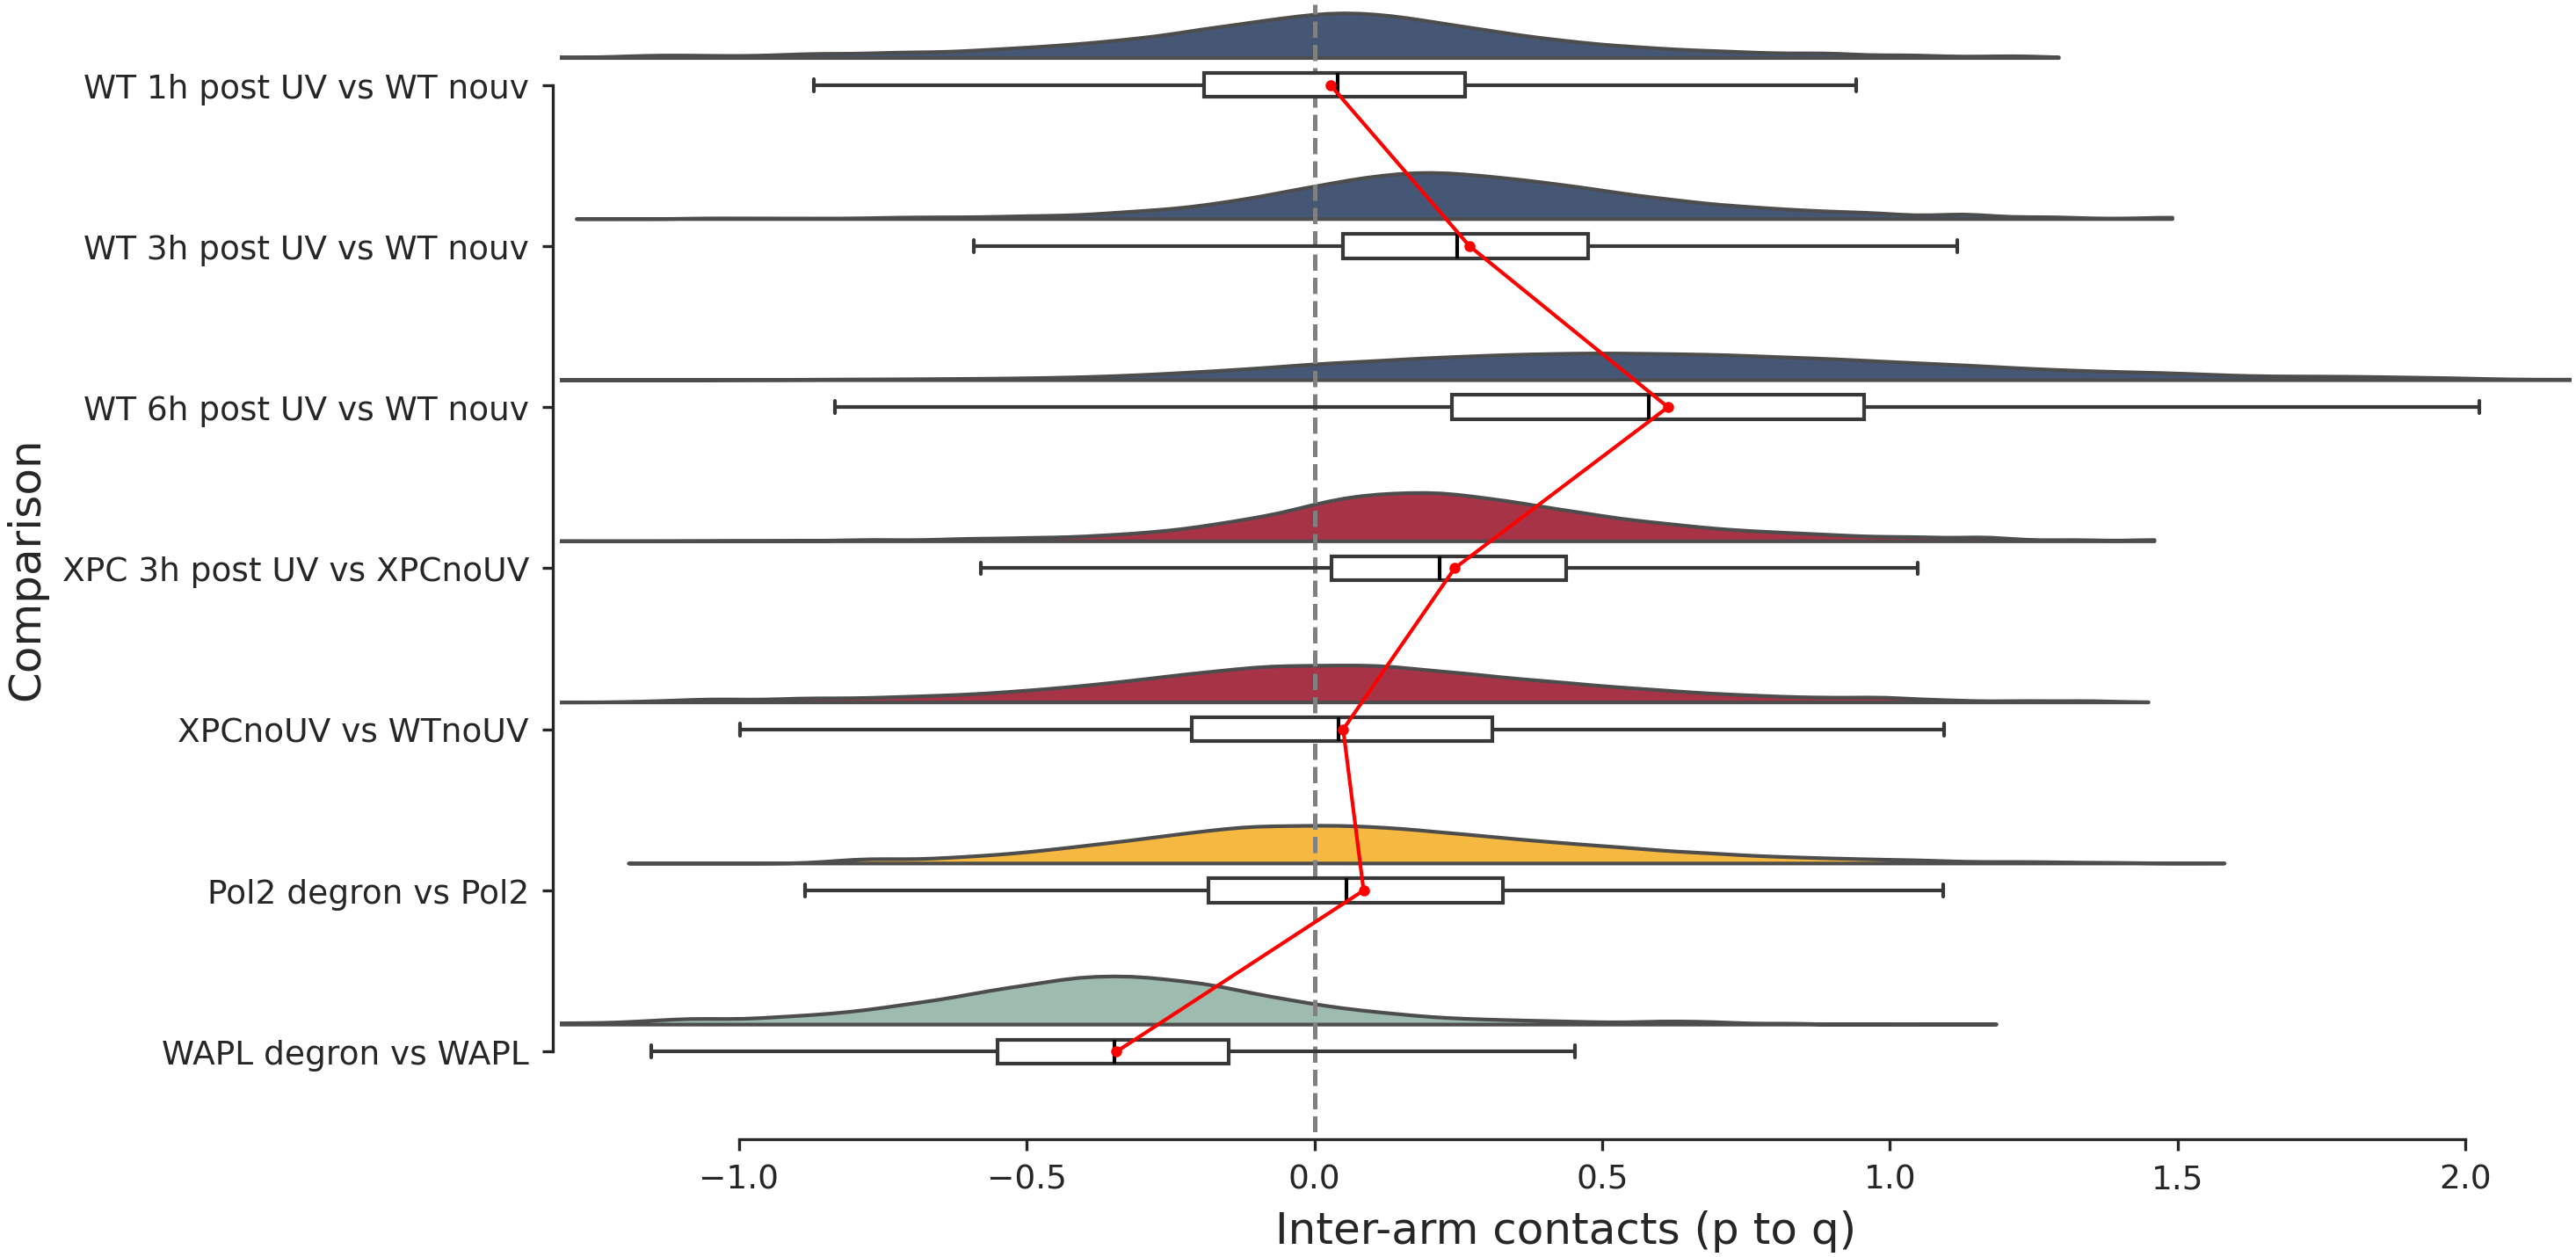

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns
import ptitprince as pt

fig, ax = plt.subplots(figsize=(10, 5))
from ggner_3d import plotting
plotting.update_rcparams()
colors = [plotting.COLORS[0], plotting.COLORS[0], plotting.COLORS[0], 
          plotting.COLORS[1], plotting.COLORS[1], 
          plotting.COLORS[2],
          plotting.COLORS[3]]

plot_df = arm_ratio_results_fixed.copy()

# keep a fixed category order
order = plot_df["comparison"].drop_duplicates().tolist()

# half density
pt.half_violinplot(
    data=plot_df,
    x="val",
    y="comparison",
    order=order,
    orient="h",
    inner=None,
    cut=0,
    width=0.6,
    offset=0.17,
    linewidth=1,
    ax=ax,
    palette=colors
)

# boxplot only
sns.boxplot(
    data=plot_df,
    x="val",
    y="comparison",
    order=order,
    orient="h",
    width=0.15,
    showfliers=False,
    boxprops={"facecolor": "white", "zorder": 3},
    whiskerprops={"zorder": 3},
    capprops={"zorder": 3},
    medianprops={"zorder": 4, "color": "black"},
    ax=ax,
    palette=colors
)

# compute means in the same order
mean_df = (
    plot_df.groupby("comparison", sort=False)["val"]
    .mean()
    .reindex(order)
    .reset_index()
)

# connect means
ypos = ax.get_yticks()
ax.plot(
    mean_df["val"].values,
    ypos,
    color="red",
    marker="o",
    linewidth=1.0,
    markersize=2,
    zorder=5
)

ax.axvline(0, color="gray", linestyle="--")

ax.set_xlabel("Inter-arm contacts (p to q)")
ax.set_ylabel("Comparison")

plotting.despine(ax=ax)
plt.tight_layout()
plt.show()